In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from xgboost import XGBClassifier

try:
    import lightgbm as lgb
    HAS_LGB = True
    print("LightGBM available")
except ImportError:
    HAS_LGB = False
    print("LightGBM not installed вЂ” skipping")

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

LightGBM available


## Reading Data

In [2]:
gold_dir = Path("../../data/gold")

ml_files = sorted(gold_dir.glob("ml_features_load_date=*.parquet"))
if not ml_files:
    raise FileNotFoundError("No ml_features parquet found. Run all_features_to_gold.ipynb first.")

latest = ml_files[-1]
df = pd.read_parquet(latest)
print(f"Loaded: {latest.name}  ->  shape {df.shape}")
print(f"\ndataset_split distribution:")
print(df['dataset_split'].value_counts())

Loaded: ml_features_load_date=2026-03-15.parquet  ->  shape (11999, 75)

dataset_split distribution:
dataset_split
train         9613
validation    1249
test          1137
Name: count, dtype: int64


In [3]:
# Keep 'check' as alias for backwards compatibility with cells below
check = df

## Organizing Columns

In [4]:
check.columns

Index(['_index', 'product_id', 'product_parent', 'label', 'dataset_split',
       'marketplace_id', 'product_category_id', 'review_date',
       'detected_language', 'vine_binary', 'verified_binary',
       'vine_x_marketplace', 'verified_x_category',
       'verified_early_interaction', 'log_review_age_days',
       'review_relative_rank', 'product_review_count', 'log_days_since_first',
       'review_month', 'review_dayofweek', 'reviews_per_day',
       'log_body_word_count', 'headline_word_count', 'has_headline',
       'type_token_ratio', 'avg_word_length', 'exclamation_density',
       'sentence_count_approx', 'body_lang_zscore', 'body_cat_zscore',
       'headline_body_ratio', 'lexical_richness', 'headline_body_cosine_sim',
       'title_body_cosine_sim', 'body_embedding_norm', 'body_sentiment_label',
       'body_sentiment_score', 'body_sentiment_polarity',
       'headline_sentiment_label', 'headline_sentiment_score',
       'headline_sentiment_polarity', 'sentiment_mismatch',


In [5]:
print(check.columns.tolist())

['_index', 'product_id', 'product_parent', 'label', 'dataset_split', 'marketplace_id', 'product_category_id', 'review_date', 'detected_language', 'vine_binary', 'verified_binary', 'vine_x_marketplace', 'verified_x_category', 'verified_early_interaction', 'log_review_age_days', 'review_relative_rank', 'product_review_count', 'log_days_since_first', 'review_month', 'review_dayofweek', 'reviews_per_day', 'log_body_word_count', 'headline_word_count', 'has_headline', 'type_token_ratio', 'avg_word_length', 'exclamation_density', 'sentence_count_approx', 'body_lang_zscore', 'body_cat_zscore', 'headline_body_ratio', 'lexical_richness', 'headline_body_cosine_sim', 'title_body_cosine_sim', 'body_embedding_norm', 'body_sentiment_label', 'body_sentiment_score', 'body_sentiment_polarity', 'headline_sentiment_label', 'headline_sentiment_score', 'headline_sentiment_polarity', 'sentiment_mismatch', 'flesch_reading_ease', 'headline_body_jaccard', 'title_body_jaccard', 'body_bigram_diversity', 'uppercas

In [6]:
_train_mask  = df['dataset_split'] == 'train'
_label_int   = df.loc[_train_mask, 'label'].astype(int)   
_vc_enc      = _label_int.groupby(df.loc[_train_mask, 'verified_x_category']).mean()
_global_mean = float(_label_int.mean())

df['verified_cat_target_enc'] = (
    df['verified_x_category'].map(_vc_enc).fillna(_global_mean)
)

print(f"Global deceptive rate (train): {_global_mean:.3f}")
print(f"Category-level range: {float(_vc_enc.min()):.3f} вЂ“ {float(_vc_enc.max()):.3f}")
print(f"NaN after mapping: {df['verified_cat_target_enc'].isna().sum()}")
print(f"\nTop 5 most deceptive categories:\n{_vc_enc.sort_values(ascending=False).head(5).round(3).to_string()}")
print(f"\nTop 5 least deceptive categories:\n{_vc_enc.sort_values().head(5).round(3).to_string()}")

Global deceptive rate (train): 0.465
Category-level range: 0.000 вЂ“ 1.000
NaN after mapping: 0

Top 5 most deceptive categories:
verified_x_category
N_27.0    1.000
N_10.0    0.821
N_6.0     0.795
N_11.0    0.787
N_14.0    0.778

Top 5 least deceptive categories:
verified_x_category
N_21.0    0.000
N_23.0    0.000
N_26.0    0.000
Y_7.0     0.077
Y_4.0     0.136


In [7]:
df['sentiment_score_x_log_words'] = df['body_sentiment_score'] * df['log_body_word_count']
df['burst_x_sentiment']           = df['reviews_in_3day_window'] * df['body_sentiment_score']
df['entropy_x_log_words']         = df['char_ngram_entropy'] * df['log_body_word_count']

df['is_english']            = (df['detected_language']   == 'en').astype(float)
df['is_french']             = (df['detected_language']   == 'fr').astype(float)

df['is_non_vine_mp1']       = (df['vine_x_marketplace']  == 'N_1.0').astype(float)

df['is_negative_sentiment'] = (df['body_sentiment_label'] == 'negative').astype(float)
df['is_positive_sentiment'] = (df['body_sentiment_label'] == 'positive').astype(float)

print("Interaction features (genuine vs deceptive means):")
for col in ['sentiment_score_x_log_words', 'burst_x_sentiment', 'entropy_x_log_words']:
    g = df.loc[df['label']==False, col].mean()
    d = df.loc[df['label']==True,  col].mean()
    print(f"  {col:35s}  genuine={g:.3f}  deceptive={d:.3f}")
print(f"\nBinary flags: is_english, is_french, is_non_vine_mp1, "
      f"is_negative_sentiment, is_positive_sentiment")


Interaction features (genuine vs deceptive means):
  sentiment_score_x_log_words          genuine=2.499  deceptive=2.728
  burst_x_sentiment                    genuine=0.060  deceptive=0.050
  entropy_x_log_words                  genuine=24.272  deceptive=35.701

Binary flags: is_english, is_french, is_non_vine_mp1, is_negative_sentiment, is_positive_sentiment


In [8]:
temporal_features = [
    'log_review_age_days', 'review_relative_rank', 'product_review_count',
    'log_days_since_first', 'review_month', 'review_dayofweek', 'reviews_per_day',
]

language_features = [
    'log_body_word_count', 'headline_word_count', 'type_token_ratio',
    'avg_word_length', 'exclamation_density',
    'sentence_count_approx', 'body_lang_zscore', 'body_cat_zscore',
    'headline_body_ratio', 'lexical_richness',
]

embedding_features = [
    'headline_body_cosine_sim', 'title_body_cosine_sim', 'body_embedding_norm',
]

sentiment_features = [
    'body_sentiment_score', 'body_sentiment_polarity',
    'uppercase_ratio', 'digit_density', 'avg_sentence_length',
    'flesch_lang_zscore', 'flesch_cat_zscore', 'polarity_lang_zscore',
    'sentiment_readability',
]

evidence_features = [
    'evidence_cat_zscore',
]

novelty_features = [
    'product_tfidf_novelty', 'product_vocab_expansion_ratio',
]

context_features = [
    'product_popularity_pctile', 'category_review_density',
    'category_product_count', 'days_since_first_x_popularity',
    'popularity_weight', 'early_x_popularity',
    'verified_cat_target_enc',
]


advanced_features = [
    'char_ngram_entropy',           
    'sentiment_arc',
    'sentiment_product_deviation',
    'sentiment_score_lang_zscore',
    'sentiment_score_x_log_words',
    'burst_x_sentiment',             
    'entropy_x_log_words',          
]

boolean_features = [
    'is_early_review', 'verified_binary', 'verified_early_interaction',
    'is_english', 'is_french',
    'is_non_vine_mp1',
    'is_negative_sentiment',
]

categorical_features = []

numeric_features = (temporal_features + language_features + embedding_features +
                    sentiment_features + evidence_features + novelty_features +
                    context_features + advanced_features)

all_features = numeric_features + boolean_features

print(f"Total features: {len(all_features)}")
print(f"  Temporal:    {len(temporal_features)}")
print(f"  Language:    {len(language_features)}  (- question_density)")
print(f"  Embedding:   {len(embedding_features)}")
print(f"  Sentiment:   {len(sentiment_features)}  (- title_body_overlap)")
print(f"  Evidence:    {len(evidence_features)}")
print(f"  Novelty:     {len(novelty_features)}")
print(f"  Context:     {len(context_features)}")
print(f"  Advanced:    {len(advanced_features)}")
print(f"  Boolean:     {len(boolean_features)}  (- is_positive_sentiment)")
missing = [f for f in all_features if f not in df.columns]
print(f"\nMissing from df: {missing if missing else 'None, all present'}")

Total features: 53
  Temporal:    7
  Language:    10  (- question_density)
  Embedding:   3
  Sentiment:   9  (- title_body_overlap)
  Evidence:    1
  Novelty:     2
  Context:     7
  Advanced:    7
  Boolean:     7  (- is_positive_sentiment)

Missing from df: None, all present


In [9]:
check_subset = df[all_features + ['label', 'dataset_split']]
check_subset.describe(include='all')

,log_review_age_days,review_relative_rank,product_review_count,log_days_since_first,review_month,review_dayofweek,reviews_per_day,log_body_word_count,headline_word_count,type_token_ratio,...,entropy_x_log_words,is_early_review,verified_binary,verified_early_interaction,is_english,is_french,is_non_vine_mp1,is_negative_sentiment,label,dataset_split
count,11729.000000,11999.000000,11999.000000,11729.000000,11729.000000,11729.000000,11999.000000,11999.000000,11999.000000,11999.000000,...,1.197800e+04,11999,11999,11999,11999.000000,11999.000000,11999.000000,11999.000000,9613,11999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,2,2,NaN,NaN,NaN,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,1.0,0.00,NaN,NaN,NaN,NaN,False,train
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6264,7739,8763,NaN,NaN,NaN,NaN,5139,9613
mean,6.520554,3.241020,5.482040,3.085038,6.347941,2.925569,0.017948,3.804115,3.492374,0.852095,...,2.936420e+01,NaN,NaN,NaN,0.332611,0.320777,0.313359,0.236020,NaN,NaN
std,1.167685,4.912749,8.071029,3.140271,3.564608,1.995134,0.085770,1.107766,3.084289,0.118741,...,1.214809e+01,NaN,NaN,NaN,0.471168,0.466795,0.463878,0.424652,NaN,NaN
min,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.693147,0.000000,0.115385,...,-1.000000e-10,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,5.905362,1.000000,1.000000,0.000000,3.000000,1.000000,0.000000,3.178054,2.000000,0.783784,...,2.146180e+01,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,6.622736,2.000000,3.000000,2.890372,6.000000,3.000000,0.003388,3.663562,3.000000,0.870968,...,2.708474e+01,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,7.246368,3.000000,6.000000,6.084499,9.000000,5.000000,0.012012,4.477337,5.000000,0.950000,...,3.717280e+01,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.000000,NaN,NaN


In [10]:
check_subset.isnull().sum()

log_review_age_days               270
review_relative_rank                0
product_review_count                0
log_days_since_first              270
review_month                      270
review_dayofweek                  270
reviews_per_day                     0
log_body_word_count                 0
headline_word_count                 0
type_token_ratio                    0
avg_word_length                     0
exclamation_density                 0
sentence_count_approx               0
body_lang_zscore                    4
body_cat_zscore                     1
headline_body_ratio                 0
lexical_richness                    0
headline_body_cosine_sim          912
title_body_cosine_sim              89
body_embedding_norm                 0
body_sentiment_score                0
body_sentiment_polarity             0
uppercase_ratio                     4
digit_density                       0
avg_sentence_length                 0
flesch_lang_zscore                  2
flesch_cat_z

## ML Models

In [11]:
train_df = df[df['dataset_split'] == 'train'].copy()

for col in boolean_features:
    train_df[col] = train_df[col].astype(float)

X_all = train_df[all_features]
y_all = train_df['label'].astype(int)

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_all, y_all, test_size=0.2, random_state=67, stratify=y_all
)

# Keep full row info for error analysis later
holdout_meta = train_df.loc[X_holdout.index, ['_index', 'log_body_word_count',
    'detected_language', 'body_sentiment_label', 'product_tfidf_novelty']].copy()

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Holdout: {X_holdout.shape[0]:,} rows")
print(f"Label balance (train) вЂ” Genuine: {(y_train==0).sum()}  Deceptive: {(y_train==1).sum()}")

Train : 7,690 rows
Holdout: 1,923 rows
Label balance (train) вЂ” Genuine: 4111  Deceptive: 3579


In [12]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

bool_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])


_transformers = [
    ('num',  numeric_transformer,  numeric_features),
    ('bool', bool_transformer,     boolean_features),
]
if categorical_features:
    _transformers.append(('cat', categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(_transformers)


def make_pipeline(clf):
    return Pipeline([('prep', preprocessor), ('classifier', clf)])

lr = make_pipeline(LogisticRegression(random_state=67, max_iter=1000, C=1.0))

rf = make_pipeline(RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    random_state=67, n_jobs=-1
))

xgb = make_pipeline(XGBClassifier(
    random_state=67, eval_metric='logloss', verbosity=0,
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
))

models = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}

if HAS_LGB:
    lgb_model = make_pipeline(lgb.LGBMClassifier(
        random_state=67, n_estimators=300, learning_rate=0.05,
        num_leaves=31, verbose=-1
    ))
    models['LightGBM'] = lgb_model


## Evaluation

In [13]:
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

print(f"{'Model':<22} {'AUC mean':>10} {'AUC std':>9} {'F1 mean':>9} {'F1 std':>8}")

cv_results = {}
for name, pipe in models.items():
    t0 = time.time()
    auc_folds, f1_folds = [], []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_all, y_all)):
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        ytr, yva = y_all.iloc[tr_idx], y_all.iloc[va_idx]
        pipe.fit(Xtr, ytr)
        prob = pipe.predict_proba(Xva)[:, 1]
        pred = pipe.predict(Xva)
        auc_folds.append(roc_auc_score(yva, prob))
        f1_folds.append(f1_score(yva, pred))
    auc_arr = np.array(auc_folds)
    f1_arr  = np.array(f1_folds)
    cv_results[name] = {'auc': auc_arr, 'f1': f1_arr}
    elapsed = time.time() - t0
    print(f"{name:<22} {auc_arr.mean():>10.4f} {auc_arr.std():>9.4f} "
          f"{f1_arr.mean():>9.4f} {f1_arr.std():>8.4f}   ({elapsed:.0f}s)")

Model                    AUC mean   AUC std   F1 mean   F1 std
Logistic Regression        0.8204    0.0086    0.7164   0.0084   (0s)
Random Forest              0.8268    0.0069    0.7207   0.0060   (3s)
XGBoost                    0.8308    0.0067    0.7250   0.0096   (2s)
LightGBM                   0.8275    0.0053    0.7205   0.0076   (4s)


In [14]:
param_dist = {
    'classifier__n_estimators':     [200, 300, 400, 500, 600],
    'classifier__max_depth':        [3, 4, 5, 6, 7],
    'classifier__learning_rate':    [0.01, 0.03, 0.05, 0.08, 0.1],
    'classifier__subsample':        [0.65, 0.7, 0.8, 0.9],
    'classifier__colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__gamma':            [0, 0.1, 0.3, 0.5],
    'classifier__reg_alpha':        [0, 0.01, 0.1, 0.5, 1.0],
    'classifier__reg_lambda':       [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=40, scoring='roc_auc', cv=cv,
    random_state=67, n_jobs=-1, verbose=0
)
search.fit(X_all, y_all)

print(f"Best XGBoost AUC (CV): {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")
best_xgb = search.best_estimator_

Best XGBoost AUC (CV): 0.8343
Best params: {'classifier__subsample': 0.65, 'classifier__reg_lambda': 1.0, 'classifier__reg_alpha': 1.0, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 5, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.03, 'classifier__gamma': 0, 'classifier__colsample_bytree': 0.6}


In [15]:
if HAS_LGB:
    lgb_param_dist = {
        'classifier__n_estimators':      [200, 300, 400, 500, 600],
        'classifier__num_leaves':        [15, 31, 50, 63, 80],
        'classifier__max_depth':         [-1, 4, 6, 8],
        'classifier__learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.1],
        'classifier__subsample':         [0.65, 0.7, 0.8, 0.9],
        'classifier__colsample_bytree':  [0.5, 0.6, 0.7, 0.8],
        'classifier__min_child_samples': [10, 20, 30, 50],
        'classifier__reg_alpha':         [0, 0.01, 0.1, 0.5, 1.0],
        'classifier__reg_lambda':        [0, 0.5, 1.0, 2.0, 5.0],
    }
    lgb_search = RandomizedSearchCV(
        models['LightGBM'], param_distributions=lgb_param_dist,
        n_iter=40, scoring='roc_auc', cv=cv,
        random_state=67, n_jobs=-1, verbose=0
    )
    lgb_search.fit(X_all, y_all)
    print(f"Best LightGBM AUC (CV): {lgb_search.best_score_:.4f}")
    print(f"Best params: {lgb_search.best_params_}")
    best_lgb = lgb_search.best_estimator_
else:
    best_lgb = None
    print("LightGBM not available вЂ” skipping tuning")

Best LightGBM AUC (CV): 0.8333
Best params: {'classifier__subsample': 0.65, 'classifier__reg_lambda': 0.5, 'classifier__reg_alpha': 0.1, 'classifier__num_leaves': 50, 'classifier__n_estimators': 500, 'classifier__min_child_samples': 30, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.6}


## Feature Importance

In [16]:
print("Training all models on 80% train split...\n")
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
if best_lgb is not None:
    best_lgb.fit(X_train, y_train)

def evaluate(name, pipeline, X, y):
    y_pred  = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_proba)
    print(f"  {name}")
    print(classification_report(y, y_pred, target_names=['Genuine', 'Deceptive']))
    print(f"  ROC-AUC: {auc:.4f}\n")
    return y_pred, y_proba

tuned_models = {'XGBoost (tuned)': best_xgb}
if best_lgb is not None:
    tuned_models['LightGBM (tuned)'] = best_lgb

results = {}
for name, pipeline in {**models, **tuned_models}.items():
    pred, proba = evaluate(name, pipeline, X_holdout, y_holdout)
    results[name] = {'pred': pred, 'proba': proba}

Training all models on 80% train split...

  Logistic Regression
              precision    recall  f1-score   support

     Genuine       0.74      0.82      0.78      1028
   Deceptive       0.76      0.66      0.71       895

    accuracy                           0.75      1923
   macro avg       0.75      0.74      0.74      1923
weighted avg       0.75      0.75      0.75      1923

  ROC-AUC: 0.8201

  Random Forest
              precision    recall  f1-score   support

     Genuine       0.74      0.83      0.78      1028
   Deceptive       0.77      0.67      0.72       895

    accuracy                           0.75      1923
   macro avg       0.76      0.75      0.75      1923
weighted avg       0.75      0.75      0.75      1923

  ROC-AUC: 0.8238

  XGBoost
              precision    recall  f1-score   support

     Genuine       0.74      0.80      0.77      1028
   Deceptive       0.75      0.67      0.71       895

    accuracy                           0.74      1923

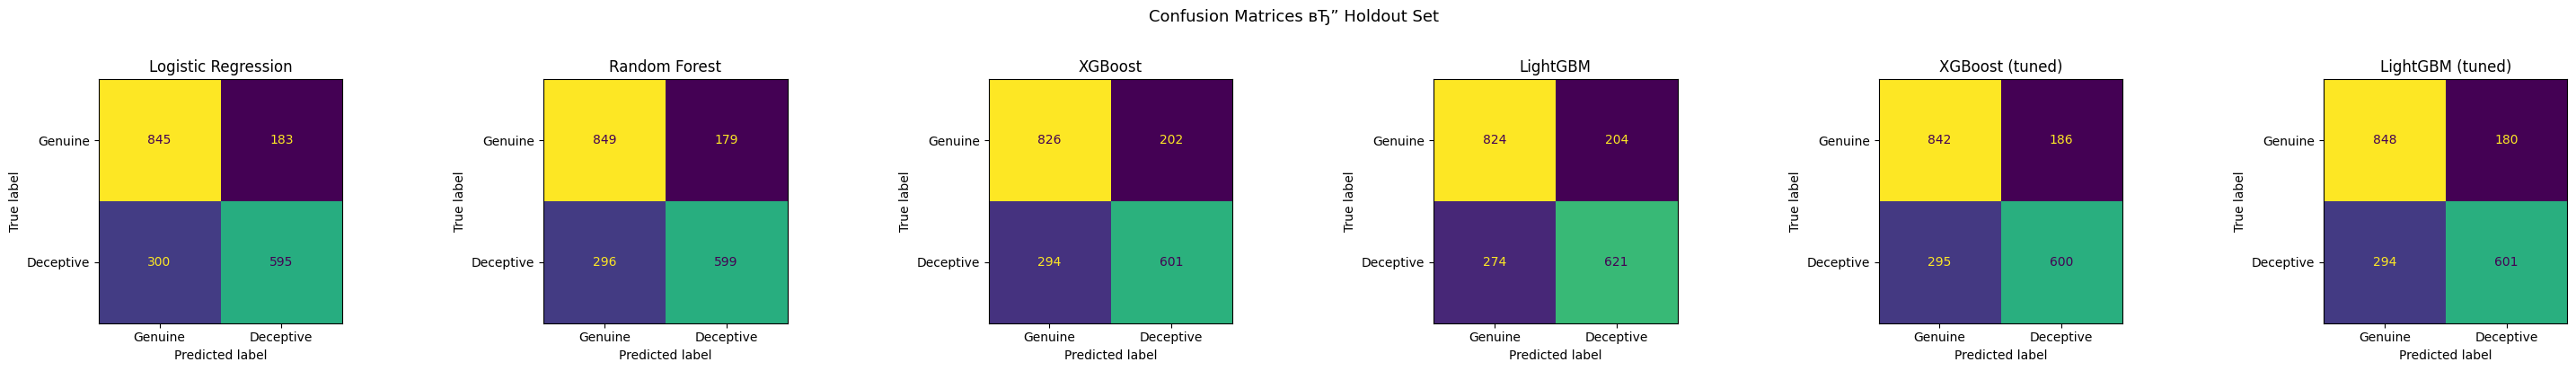

In [17]:
model_names = list(results.keys())
fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4))
if len(model_names) == 1:
    axes = [axes]

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_holdout, results[name]['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Genuine', 'Deceptive']).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrices вЂ” Holdout Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

XGBoost вЂ” Top 20 features:
char_ngram_entropy               0.1449
entropy_x_log_words              0.1154
log_review_age_days              0.0495
verified_cat_target_enc          0.0356
is_non_vine_mp1                  0.0311
verified_binary                  0.0307
log_body_word_count              0.0283
verified_early_interaction       0.0220
body_lang_zscore                 0.0215
days_since_first_x_popularity    0.0211
is_negative_sentiment            0.0206
category_review_density          0.0201
log_days_since_first             0.0190
is_french                        0.0181
body_sentiment_polarity          0.0178
body_embedding_norm              0.0168
body_cat_zscore                  0.0163
polarity_lang_zscore             0.0162
review_relative_rank             0.0159
early_x_popularity               0.0145

Features with importance < 0.003: 0 columns

LightGBM вЂ” Top 20 features:
log_review_age_days              1567
polarity_lang_zscore              661
verified_cat_target

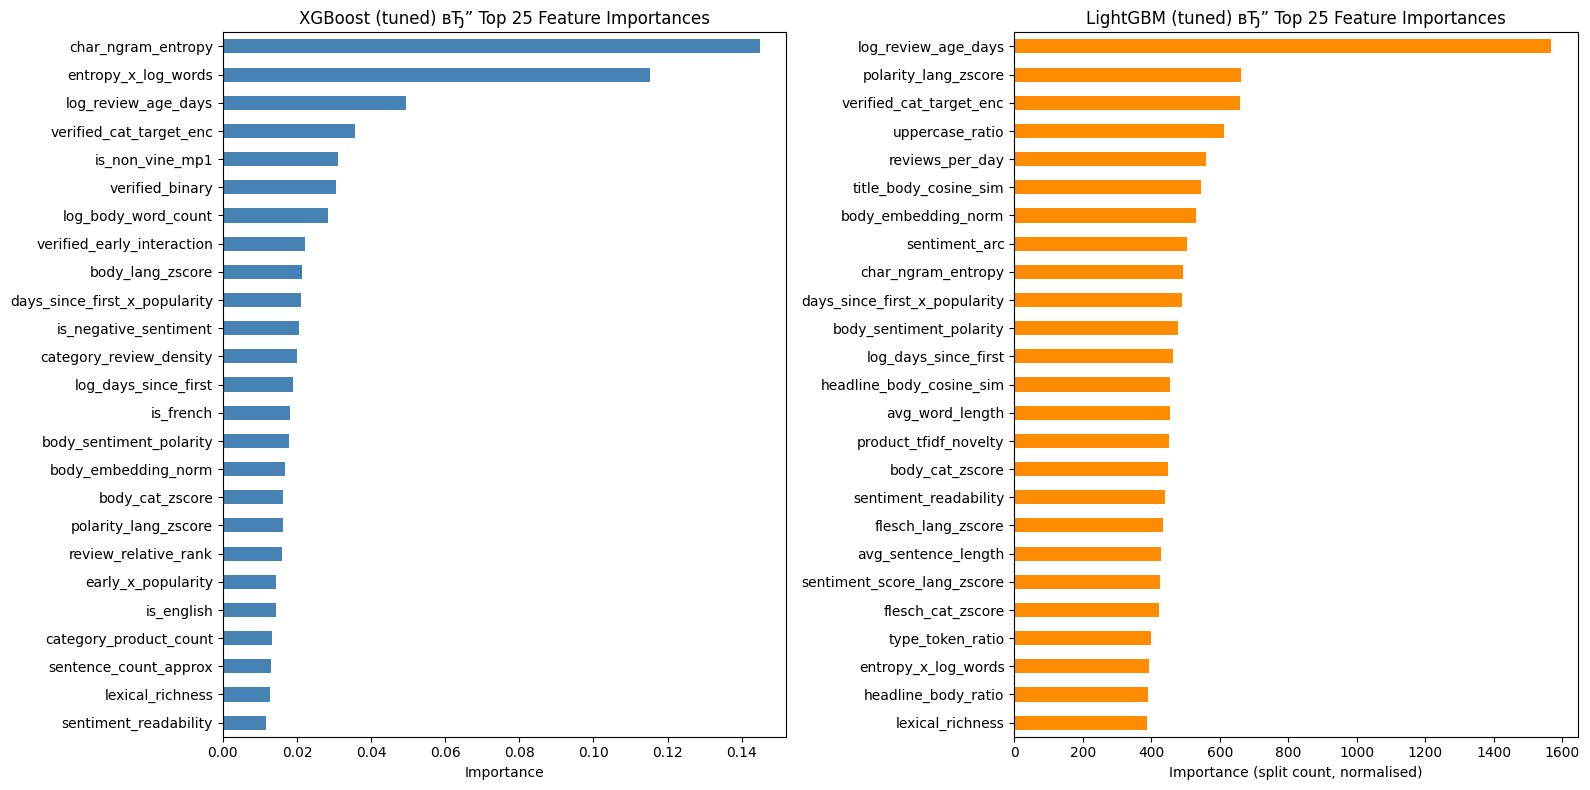

In [18]:
feature_names = numeric_features + boolean_features
importances   = best_xgb.named_steps['classifier'].feature_importances_

feat_imp = (pd.Series(importances, index=feature_names)
              .sort_values(ascending=False))

print("XGBoost вЂ” Top 20 features:")
print(feat_imp.head(20).round(4).to_string())

low_importance = feat_imp[feat_imp < 0.003].index.tolist()
print(f"\nFeatures with importance < 0.003: {len(low_importance)} columns")
if low_importance:
    print(f"  {low_importance}")

# LightGBM importances
if best_lgb is not None:
    lgb_imp = pd.Series(
        best_lgb.named_steps['classifier'].feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
    print("\nLightGBM вЂ” Top 20 features:")
    print(lgb_imp.head(20).round(4).to_string())

# Plot top 25 for each
n_plots = 2 if best_lgb is not None else 1
fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 8))
if n_plots == 1:
    axes = [axes]

feat_imp.head(25).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost (tuned) вЂ” Top 25 Feature Importances')
axes[0].set_xlabel('Importance')

if best_lgb is not None:
    lgb_imp.head(25).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
    axes[1].set_title('LightGBM (tuned) вЂ” Top 25 Feature Importances')
    axes[1].set_xlabel('Importance (split count, normalised)')

plt.tight_layout()
plt.show()

Importance by group
            total   n    mean     min
group                                
Advanced   0.3085   7  0.0441  0.0081
Boolean    0.1454   7  0.0208  0.0085
Language   0.1407  10  0.0141  0.0083
Context    0.1241   7  0.0177  0.0097
Temporal   0.1219   7  0.0174  0.0084
Sentiment  0.0983   9  0.0109  0.0082
Embedding  0.0339   3  0.0113  0.0083
Novelty    0.0178   2  0.0089  0.0084
Evidence   0.0094   1  0.0094  0.0094

Advanced      [total=0.3085]
     char_ngram_entropy                       0.1449
     entropy_x_log_words                      0.1154
     burst_x_sentiment                        0.0114
     sentiment_score_x_log_words              0.0099
     sentiment_product_deviation              0.0097
     sentiment_score_lang_zscore              0.0092
     sentiment_arc                            0.0081

Boolean       [total=0.1454]
     is_non_vine_mp1                          0.0311
     verified_binary                          0.0307
     verified_early_inter

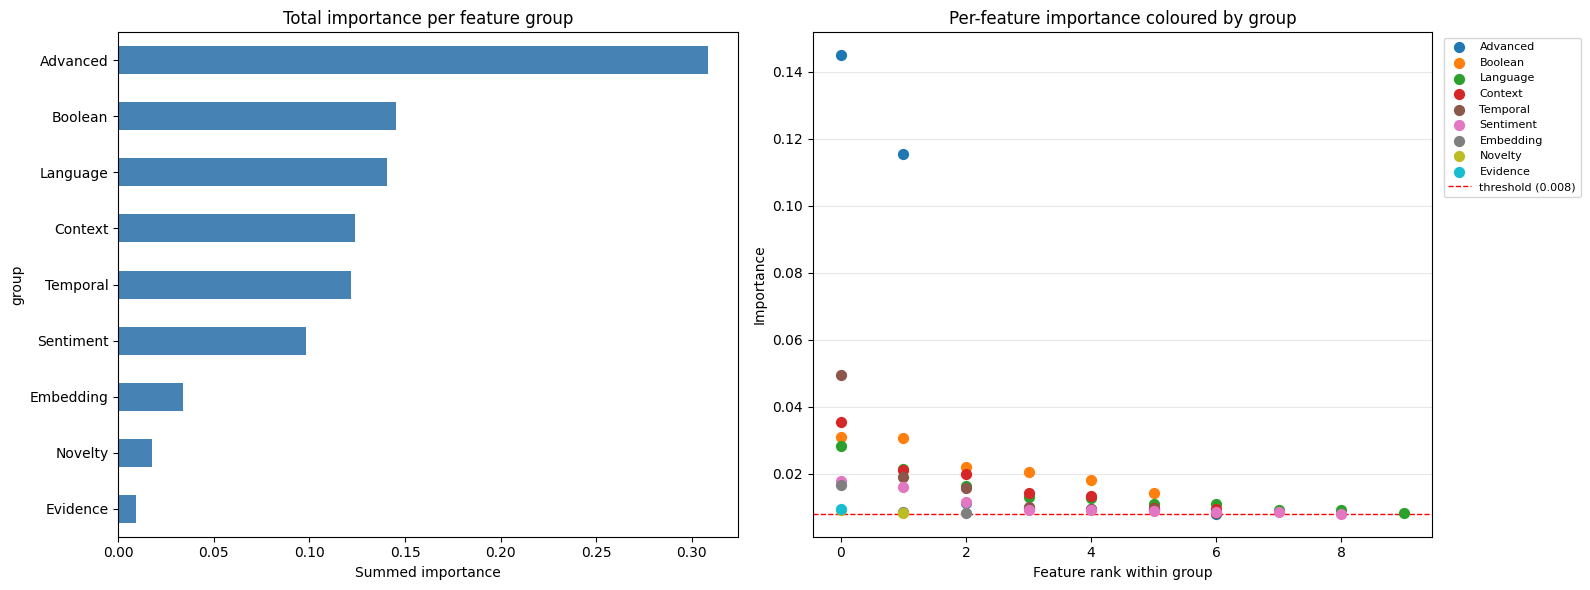

In [19]:
_group_map = (
    [(f, 'Temporal')   for f in temporal_features]  +
    [(f, 'Language')   for f in language_features]  +
    [(f, 'Embedding')  for f in embedding_features] +
    [(f, 'Sentiment')  for f in sentiment_features] +
    [(f, 'Evidence')   for f in evidence_features]  +
    [(f, 'Novelty')    for f in novelty_features]   +
    [(f, 'Context')    for f in context_features]   +
    [(f, 'Advanced')   for f in advanced_features]  +
    [(f, 'Boolean')    for f in boolean_features]
)
group_lookup = dict(_group_map)

feat_imp_df = feat_imp.reset_index()
feat_imp_df.columns = ['feature', 'importance']
feat_imp_df['group'] = feat_imp_df['feature'].map(group_lookup)

group_totals = (feat_imp_df.groupby('group')['importance']
                .agg(total='sum', n='count', mean='mean', min='min')
                .sort_values('total', ascending=False)
                .round(4))
print("Importance by group")
print(group_totals.to_string())

WARN_THRESHOLD = 0.008   

for grp in group_totals.index:
    sub = feat_imp_df[feat_imp_df['group'] == grp].sort_values('importance', ascending=False)
    total = sub['importance'].sum()
    print(f"\n{grp:12s}  [total={total:.4f}]")
    for _, row in sub.iterrows():
        flag = ' !' if row['importance'] < WARN_THRESHOLD else '  '
        print(f"  {flag} {row['feature']:<40s} {row['importance']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

group_totals['total'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total importance per feature group')
axes[0].set_xlabel('Summed importance')

import matplotlib.cm as cm
groups_ordered = group_totals.index.tolist()
colours = cm.tab10(np.linspace(0, 1, len(groups_ordered)))
colour_map = dict(zip(groups_ordered, colours))
for grp, col in colour_map.items():
    sub = feat_imp_df[feat_imp_df['group'] == grp].sort_values('importance', ascending=False)
    axes[1].scatter(range(len(sub)), sub['importance'], label=grp, color=col, s=50, zorder=3)
axes[1].axhline(WARN_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'threshold ({WARN_THRESHOLD})')
axes[1].set_title('Per-feature importance coloured by group')
axes[1].set_xlabel('Feature rank within group')
axes[1].set_ylabel('Importance')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Error Analysis

In [20]:
err_df = holdout_meta.copy()
err_df['y_true']    = y_holdout.values
err_df['y_pred']    = results['XGBoost (tuned)']['pred']
err_df['y_proba']   = results['XGBoost (tuned)']['proba']
err_df['correct']   = (err_df['y_true'] == err_df['y_pred'])
err_df['body_words'] = np.expm1(err_df['log_body_word_count']).round(0).astype(int)

print(f"Overall holdout accuracy: {err_df['correct'].mean():.3f}")
print(f"Errors: {(~err_df['correct']).sum()} / {len(err_df)}\n")

err_df['length_bucket'] = pd.cut(err_df['body_words'],
    bins=[0, 10, 30, 80, 200, 99999],
    labels=['<10', '10-30', '30-80', '80-200', '>200'])

print("Error rate by review length:")
length_err = err_df.groupby('length_bucket', observed=True)['correct'].agg(['mean','count'])
length_err.columns = ['accuracy', 'count']
length_err['error_rate'] = (1 - length_err['accuracy']).round(3)
print(length_err[['count','error_rate']].to_string())

print("\nError rate by detected language (top 8):")
lang_err = (err_df.groupby('detected_language')['correct']
            .agg(['mean','count'])
            .rename(columns={'mean':'accuracy','count':'n'})
            .sort_values('n', ascending=False)
            .head(8))
lang_err['error_rate'] = (1 - lang_err['accuracy']).round(3)
print(lang_err[['n','error_rate']].to_string())

print("\nError rate by body sentiment:")
sent_err = (err_df.groupby('body_sentiment_label')['correct']
            .agg(['mean','count'])
            .rename(columns={'mean':'accuracy','count':'n'}))
sent_err['error_rate'] = (1 - sent_err['accuracy']).round(3)
print(sent_err[['n','error_rate']].to_string())

print("\nMean prediction confidence:")
print(f"  Correct predictions:   {err_df.loc[err_df['correct'],  'y_proba'].apply(lambda p: max(p, 1-p)).mean():.3f}")
print(f"  Incorrect predictions: {err_df.loc[~err_df['correct'], 'y_proba'].apply(lambda p: max(p, 1-p)).mean():.3f}")

Overall holdout accuracy: 0.750
Errors: 481 / 1923

Error rate by review length:
               count  error_rate
length_bucket                   
<10              145       0.062
10-30            668       0.268
30-80            592       0.323
80-200           329       0.231
>200             189       0.138

Error rate by detected language (top 8):
                     n  error_rate
detected_language                 
en                 662       0.224
fr                 606       0.290
de                 450       0.231
hu                 136       0.353
unknown             34       0.059
vi                  15       0.133
af                   4       0.000
ca                   4       0.000

Error rate by body sentiment:
                         n  error_rate
body_sentiment_label                  
negative               473       0.275
neutral                248       0.226
positive              1202       0.245

Mean prediction confidence:
  Correct predictions:   0.787
  Incorrec

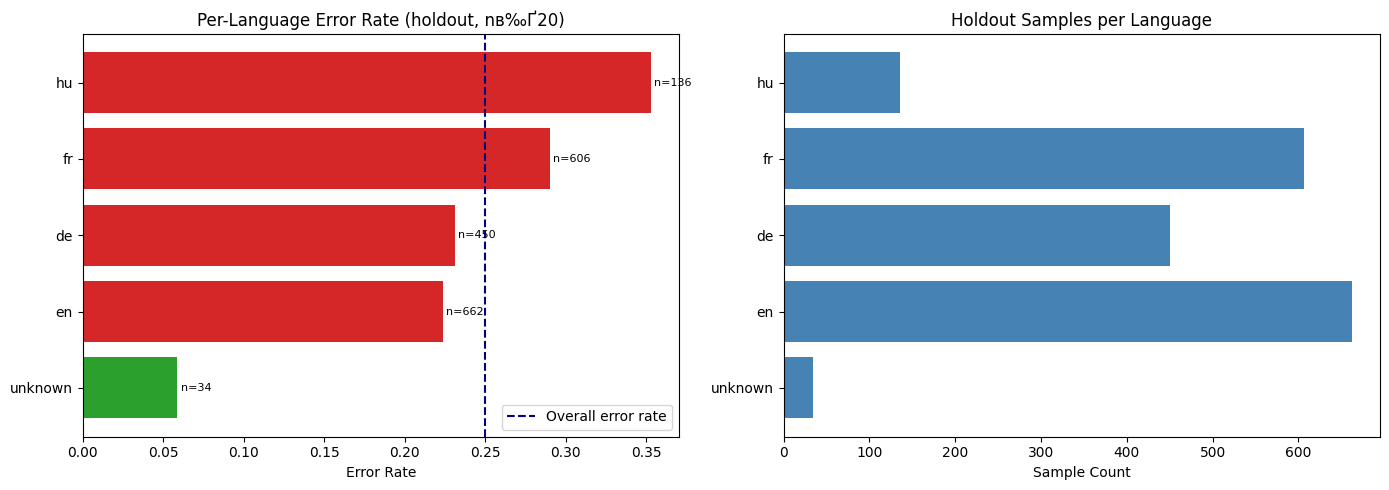


Full per-language breakdown:
                   accuracy    n  error_rate
detected_language                           
en                 0.776435  662       0.224
fr                 0.709571  606       0.290
de                 0.768889  450       0.231
hu                 0.647059  136       0.353
unknown            0.941176   34       0.059
vi                 0.866667   15       0.133
af                 1.000000    4       0.000
ca                 1.000000    4       0.000
it                 1.000000    3       0.000
ro                 1.000000    2       0.000
cy                 1.000000    2       0.000
da                 1.000000    1       0.000
et                 0.000000    1       1.000
es                 1.000000    1       0.000
pt                 1.000000    1       0.000
sl                 1.000000    1       0.000


In [21]:
_lang_stats = (
    err_df.groupby('detected_language')['correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n'})
    .assign(error_rate=lambda d: 1 - d['accuracy'])
    .sort_values('n', ascending=False)
)

_lang_plot = _lang_stats[_lang_stats['n'] >= 20].sort_values('error_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#d62728' if e > 0.15 else '#2ca02c' for e in _lang_plot['error_rate']]
axes[0].barh(_lang_plot.index, _lang_plot['error_rate'], color=colors)
axes[0].axvline(x=err_df['correct'].mean().__rsub__(1), color='navy',
                linestyle='--', linewidth=1.5, label='Overall error rate')
axes[0].set_xlabel('Error Rate')
axes[0].set_title('Per-Language Error Rate (holdout, nв‰Ґ20)')
axes[0].legend()
for i, (lang, row) in enumerate(_lang_plot.iterrows()):
    axes[0].text(row['error_rate'] + 0.002, i, f"n={row['n']:.0f}", va='center', fontsize=8)

axes[1].barh(_lang_plot.index, _lang_plot['n'], color='steelblue')
axes[1].set_xlabel('Sample Count')
axes[1].set_title('Holdout Samples per Language')

plt.tight_layout()
plt.show()

print("\nFull per-language breakdown:")
print(_lang_stats.assign(error_rate=lambda d: d['error_rate'].round(3)).to_string())


Group                Feats     AUC
Temporal                 7  0.7638
Language                17  0.8156
Sentiment               26  0.8157
Evidence                27  0.8214
Novelty                 29  0.8223
Context                 36  0.8215
Advanced                43  0.8256
Boolean                 50  0.8286
Categorical             50  0.8286
Embedding               53  0.8285


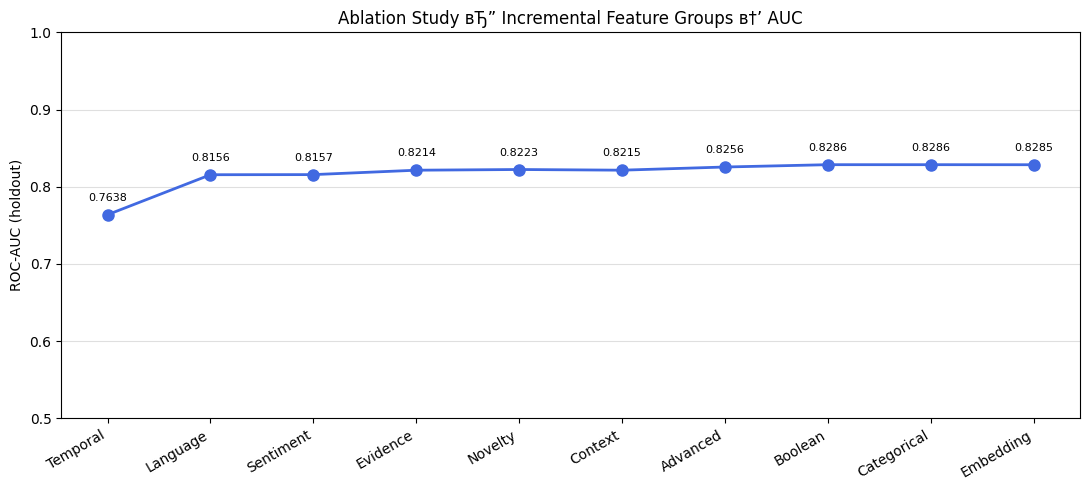

In [22]:
from sklearn.compose import ColumnTransformer as _CT
from sklearn.pipeline import Pipeline as _Pipe
from sklearn.preprocessing import StandardScaler as _SS, OneHotEncoder as _OHE
from sklearn.impute import SimpleImputer as _SI
from xgboost import XGBClassifier as _XGB

_num_set  = set(numeric_features)
_bool_set = set(boolean_features)
_cat_set  = set(categorical_features)

def _ablation_pipeline(feat_list):
    """Build a fresh XGBoost pipeline for a given feature subset."""
    nf = [f for f in feat_list if f in _num_set]
    bf = [f for f in feat_list if f in _bool_set]
    cf = [f for f in feat_list if f in _cat_set]
    transformers = []
    if nf:
        transformers.append(('num', _Pipe([
            ('imp', _SI(strategy='median')), ('sc', _SS())]), nf))
    if bf:
        transformers.append(('bool', _SI(strategy='constant', fill_value=0), bf))
    if cf:
        transformers.append(('cat', _Pipe([
            ('imp', _SI(strategy='constant', fill_value='unknown')),
            ('enc', _OHE(handle_unknown='ignore', sparse_output=False))]), cf))
    prep = _CT(transformers)
    return _Pipe([('prep', prep), ('clf', _XGB(
        random_state=67, eval_metric='logloss', verbosity=0,
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
    ))])


_ablation_groups = [
    ('Temporal',    temporal_features),
    ('Language',    language_features),
    ('Sentiment',   sentiment_features),
    ('Evidence',    evidence_features),
    ('Novelty',     novelty_features),
    ('Context',     context_features),
    ('Advanced',    advanced_features),
    ('Boolean',     boolean_features),
    ('Categorical', categorical_features),
    ('Embedding',   embedding_features),   
]

_cumulative, _auc_scores, _group_labels = [], [], []
print(f"{'Group':<20} {'Feats':>5}  {'AUC':>6}")
for _gname, _gfeats in _ablation_groups:
    _cumulative += _gfeats
    _pipe = _ablation_pipeline(_cumulative)
    _pipe.fit(X_train[_cumulative], y_train)
    _proba = _pipe.predict_proba(X_holdout[_cumulative])[:, 1]
    _auc = roc_auc_score(y_holdout, _proba)
    _auc_scores.append(_auc)
    _group_labels.append(_gname)
    print(f"{_gname:<20} {len(_cumulative):>5}  {_auc:.4f}")

# Plot AUC vs cumulative feature groups
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(_group_labels)), _auc_scores, marker='o', linewidth=2,
        color='royalblue', markersize=8)
for i, (lbl, auc) in enumerate(zip(_group_labels, _auc_scores)):
    ax.annotate(f'{auc:.4f}', (i, auc), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8)
ax.set_xticks(range(len(_group_labels)))
ax.set_xticklabels(_group_labels, rotation=30, ha='right')
ax.set_ylabel('ROC-AUC (holdout)')
ax.set_title('Ablation Study вЂ” Incremental Feature Groups в†’ AUC')
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

Error type counts:
error_type
Correct                     1442
FN (Deceptiveв†’Genuine)     295
FP (Genuineв†’Deceptive)     186

Mean feature values by error type:
error_type                Correct  FN (Deceptiveв†’Genuine)  FP (Genuineв†’Deceptive)
char_ngram_entropy         7.3228                    7.1416                    8.0527
entropy_x_log_words       29.4842                   25.5233                   35.9611
log_body_word_count        3.8054                    3.5074                    4.3931
product_tfidf_novelty      0.8953                    0.8905                    0.9092
body_sentiment_score       0.7099                    0.7667                    0.6473
sentiment_arc             -0.0448                   -0.0368                   -0.0607
type_token_ratio           0.8519                    0.8850                    0.7992
headline_body_cosine_sim   0.3221                    0.3256                    0.3307
verified_cat_target_enc    0.4675                    0.3923  

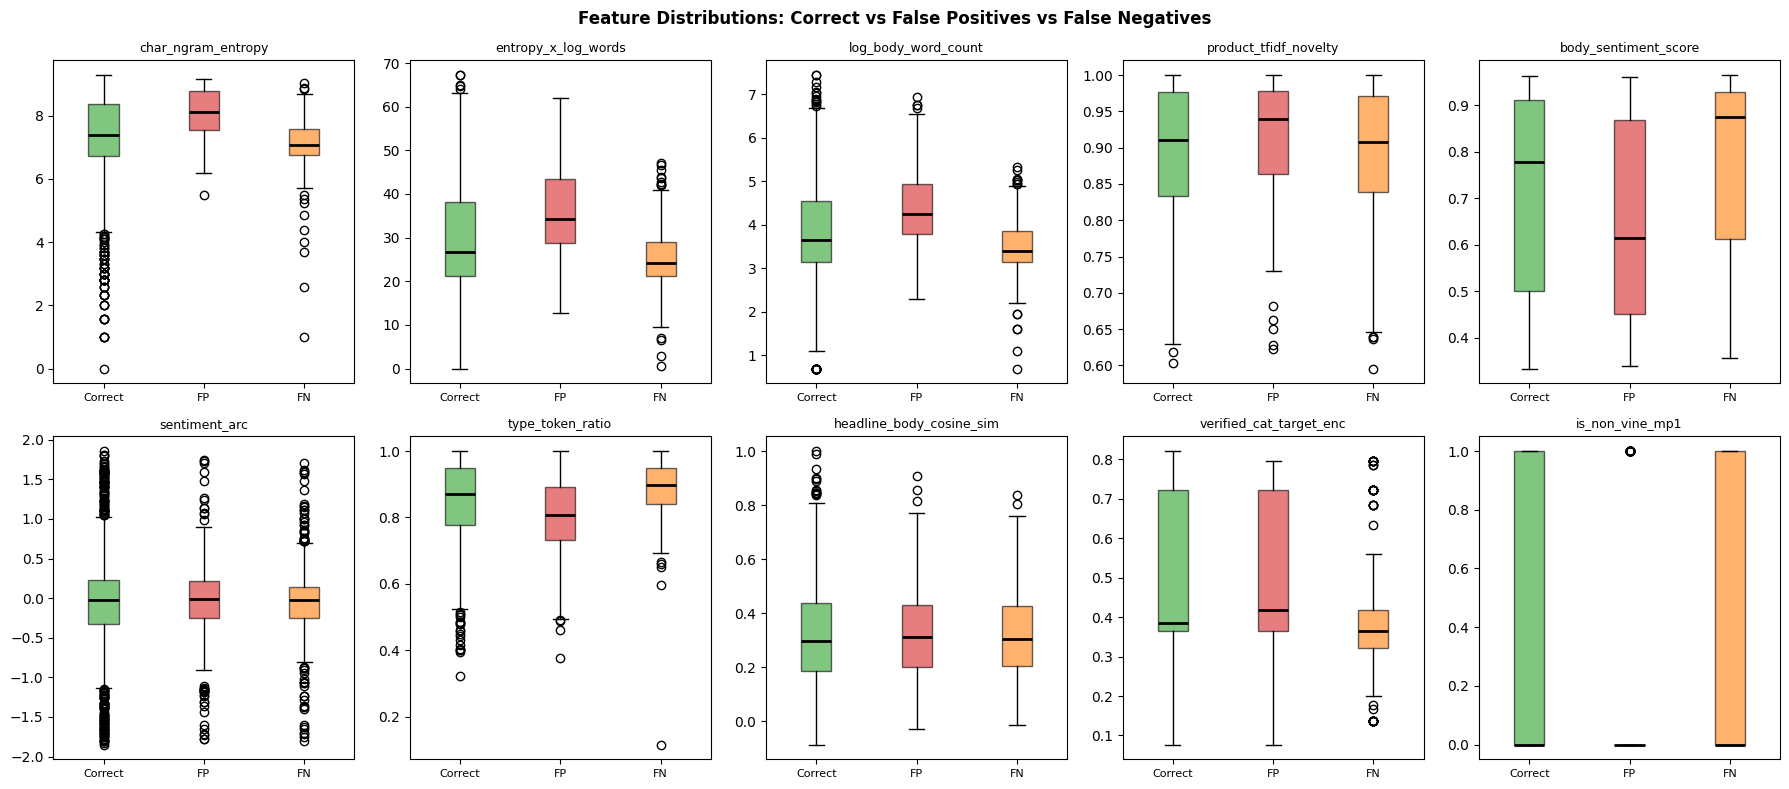

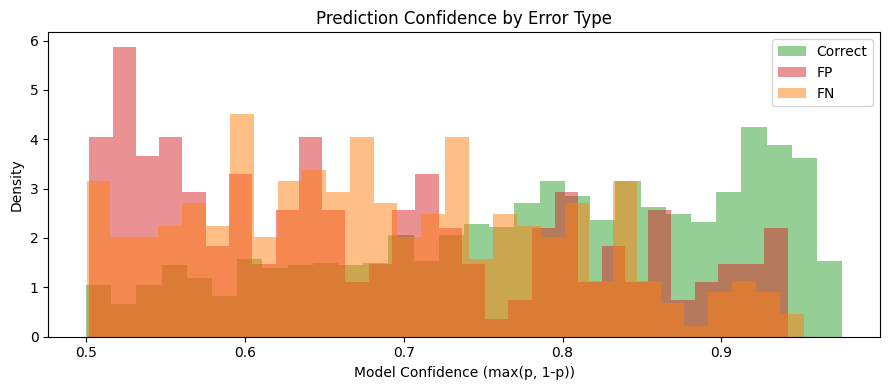

In [23]:
# Join holdout features with error labels
_sig = X_holdout.copy()
_sig['y_true'] = y_holdout.values
_sig['y_pred'] = results['XGBoost (tuned)']['pred']
_sig['y_proba'] = results['XGBoost (tuned)']['proba']

_sig['error_type'] = 'Correct'
_sig.loc[(_sig['y_true'] == 0) & (_sig['y_pred'] == 1), 'error_type'] = 'FP (Genuineв†’Deceptive)'
_sig.loc[(_sig['y_true'] == 1) & (_sig['y_pred'] == 0), 'error_type'] = 'FN (Deceptiveв†’Genuine)'

print("Error type counts:")
print(_sig['error_type'].value_counts().to_string())

# Key numeric features to compare across error types
_key_feats = [
    'char_ngram_entropy', 'entropy_x_log_words', 'log_body_word_count',
    'product_tfidf_novelty', 'body_sentiment_score', 'sentiment_arc',
    'type_token_ratio', 'headline_body_cosine_sim', 'verified_cat_target_enc',
    'is_non_vine_mp1',
]
_key_feats = [f for f in _key_feats if f in _sig.columns]

# Mean feature values by error type
_profile = _sig.groupby('error_type')[_key_feats].mean().T
print("\nMean feature values by error type:")
print(_profile.round(4).to_string())

# Boxplot grid
_fp = _sig[_sig['error_type'] == 'FP (Genuineв†’Deceptive)']
_fn = _sig[_sig['error_type'] == 'FN (Deceptiveв†’Genuine)']
_ok = _sig[_sig['error_type'] == 'Correct']

ncols = 5
nrows = -(-len(_key_feats) // ncols)   
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for ax, feat in zip(axes, _key_feats):
    data = [_ok[feat].dropna(), _fp[feat].dropna(), _fn[feat].dropna()]
    bp = ax.boxplot(data, patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
    colors_box = ['#2ca02c', '#d62728', '#ff7f0e']
    for patch, c in zip(bp['boxes'], colors_box):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Correct', 'FP', 'FN'], fontsize=8)
    ax.set_title(feat, fontsize=9)

for ax in axes[len(_key_feats):]:
    ax.set_visible(False)

fig.suptitle('Feature Distributions: Correct vs False Positives vs False Negatives',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Confidence distribution of errors
fig, ax = plt.subplots(figsize=(9, 4))
for label, subset, color in [
    ('Correct',  _ok,  '#2ca02c'),
    ('FP',       _fp,  '#d62728'),
    ('FN',       _fn,  '#ff7f0e'),
]:
    conf = subset['y_proba'].apply(lambda p: max(p, 1 - p))
    ax.hist(conf, bins=30, alpha=0.5, label=label, color=color, density=True)
ax.set_xlabel('Model Confidence (max(p, 1-p))')
ax.set_ylabel('Density')
ax.set_title('Prediction Confidence by Error Type')
ax.legend()
plt.tight_layout()
plt.show()


## Predictions on Unlabeled Splits

In [24]:
best_xgb_final = search.best_estimator_
best_xgb_final.fit(X_all, y_all)

for split in ['validation', 'test']:
    split_df = df[df['dataset_split'] == split].copy()
    for col in boolean_features:
        split_df[col] = split_df[col].astype(float)

    X_split = split_df[all_features]
    preds   = best_xgb_final.predict(X_split)
    probas  = best_xgb_final.predict_proba(X_split)[:, 1]

    pred_df = pd.DataFrame({
        '_index':           split_df['_index'].values,
        'product_id':       split_df['product_id'].values,
        'predicted_label':  preds,
        'proba_deceptive':  probas.round(4),
    })

    out_path = Path(f'../../data/gold/predictions_{split}.parquet')
    pred_df.to_parquet(out_path, index=False)

    deceptive_pct = preds.mean() * 100
    print(f"[{split}]  {len(pred_df):,} rows  |  "
          f"Predicted deceptive: {deceptive_pct:.1f}%  |  Saved в†’ {out_path.name}")

[validation]  1,249 rows  |  Predicted deceptive: 38.7%  |  Saved в†’ predictions_validation.parquet
[test]  1,137 rows  |  Predicted deceptive: 39.1%  |  Saved в†’ predictions_test.parquet
